In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
print('Import complete')

Import complete


In [2]:
data = pd.read_csv('customer_churn_dataset.csv')
data

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [3]:
data.shape

(440833, 12)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [5]:
data.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [6]:
data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [7]:
data = data.drop('CustomerID',axis = 1)
data.head(10)

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
5,51.0,Male,33.0,25.0,9.0,26.0,Premium,Annual,129.0,8.0,1.0
6,58.0,Female,49.0,12.0,3.0,16.0,Standard,Quarterly,821.0,24.0,1.0
7,55.0,Female,37.0,8.0,4.0,15.0,Premium,Annual,445.0,30.0,1.0
8,39.0,Male,12.0,5.0,7.0,4.0,Standard,Quarterly,969.0,13.0,1.0
9,64.0,Female,3.0,25.0,2.0,11.0,Standard,Quarterly,415.0,29.0,1.0


In [8]:
maleCustomers = data[data['Gender']=="Male"]['Gender'].count()
femaleCustomers = data[data['Gender']=="Female"]['Gender'].count()
print(f'Male Customers are {maleCustomers} and Female Customers are {femaleCustomers}.')
maleProp = maleCustomers/len(data)
femaleProp = femaleCustomers/len(data)
print(f'Male Proportion : {maleProp} , Female Proportion : {femaleProp}')

Male Customers are 250252 and Female Customers are 190580.
Male Proportion : 0.5676798243325704 , Female Proportion : 0.4323179072347125


In [9]:
data.groupby('Gender')['Churn'].sum()

Gender
Female    127058.0
Male      122941.0
Name: Churn, dtype: float64

In [10]:
MaleChurn = data[data['Gender']=='Male']['Churn'].sum()
FemaleChurn = data[data['Gender']=='Female']['Churn'].sum()
print(f"Male Churning Probability : {MaleChurn/maleCustomers} , Female Churning Probability : {FemaleChurn/femaleCustomers}")

Male Churning Probability : 0.4912688010485431 , Female Churning Probability : 0.6666911533214398


In [11]:
# According to data, Female has higher probability of churning in general, So gender is an important variable and
# we can not drop it

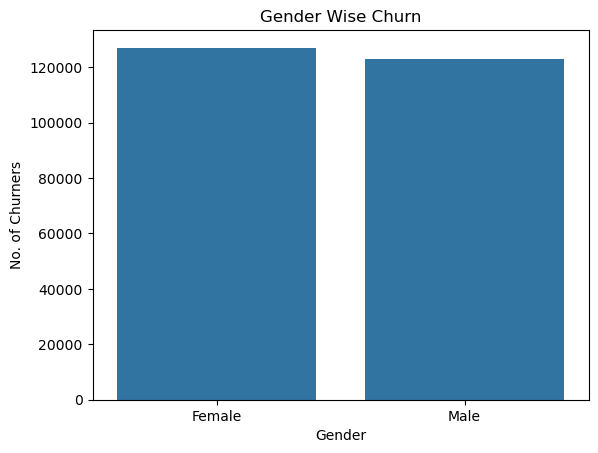

In [12]:
sns.barplot(data=data, x='Gender', y='Churn', estimator=sum, errorbar=None)
plt.title('Gender Wise Churn')
plt.ylabel('No. of Churners')
plt.show()

In [13]:
data.head(12)

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
5,51.0,Male,33.0,25.0,9.0,26.0,Premium,Annual,129.0,8.0,1.0
6,58.0,Female,49.0,12.0,3.0,16.0,Standard,Quarterly,821.0,24.0,1.0
7,55.0,Female,37.0,8.0,4.0,15.0,Premium,Annual,445.0,30.0,1.0
8,39.0,Male,12.0,5.0,7.0,4.0,Standard,Quarterly,969.0,13.0,1.0
9,64.0,Female,3.0,25.0,2.0,11.0,Standard,Quarterly,415.0,29.0,1.0


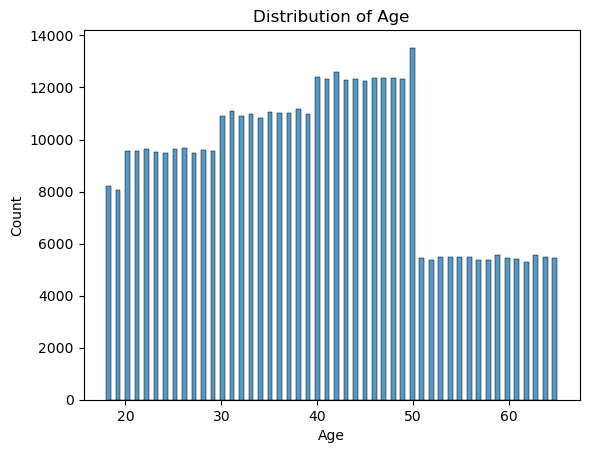

In [14]:
sns.histplot(data = data,x = 'Age')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

In [15]:
# So our data is distributed accross different age groups uniformly which means almost every age group data 
# is being represented from 18 to 65 though older people are lesser comparitevly

In [16]:
data['Age'].min()

18.0

In [17]:
data['Age'].max()

65.0

In [18]:
def AgeGroup(x):
    if x > 18 and x <30:
        return "Young"
    elif x >= 30 and x < 50:
        return "Mature"
    else:
        return "Old"

    return ""
    

In [19]:
data['AgeGroup'] = data['Age'].apply(AgeGroup)

In [20]:
data.head(10)

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,AgeGroup
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,Mature
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,Old
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,Old
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,Old
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,Young
5,51.0,Male,33.0,25.0,9.0,26.0,Premium,Annual,129.0,8.0,1.0,Old
6,58.0,Female,49.0,12.0,3.0,16.0,Standard,Quarterly,821.0,24.0,1.0,Old
7,55.0,Female,37.0,8.0,4.0,15.0,Premium,Annual,445.0,30.0,1.0,Old
8,39.0,Male,12.0,5.0,7.0,4.0,Standard,Quarterly,969.0,13.0,1.0,Mature
9,64.0,Female,3.0,25.0,2.0,11.0,Standard,Quarterly,415.0,29.0,1.0,Old


In [21]:
data.groupby('AgeGroup')['Churn'].mean()

AgeGroup
Mature    0.433665
Old       0.887950
Young     0.547844
Name: Churn, dtype: float64

In [22]:
data.groupby('AgeGroup')['Churn'].count()

AgeGroup
Mature    233625
Old       103400
Young     103807
Name: Churn, dtype: int64

In [23]:
# From that we came to know that in Older People Churning rate is comparitevly higher so we can not ignore age during
# ML Training

In [24]:
data.groupby('Subscription Type')['Churn'].mean()

Subscription Type
Basic       0.581782
Premium     0.559417
Standard    0.560700
Name: Churn, dtype: float64

In [25]:
data.groupby('Subscription Type')['Churn'].count()

Subscription Type
Basic       143026
Premium     148678
Standard    149128
Name: Churn, dtype: int64

In [26]:
# So from that we came to know that the sample size is decent for all categories and the probability of churning
# is quite similar.

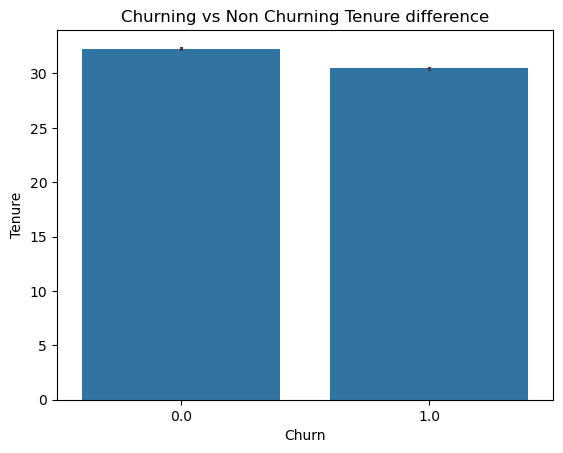

In [27]:
sns.barplot(data = data, x= 'Churn',y ='Tenure' )
plt.title('Churning vs Non Churning Tenure difference')
plt.show()

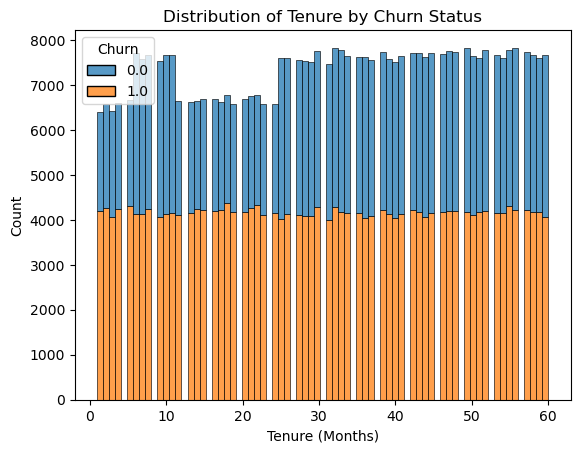

In [28]:
sns.histplot(data=data, x='Tenure', hue='Churn', multiple='stack')
plt.title('Distribution of Tenure by Churn Status')
plt.xlabel('Tenure (Months)')
plt.show()

In [29]:
# This shows that Customers churn at a steady, fixed rate regardless of how long they’ve been with us, 
# meaning long tenure does not improve customer retention.

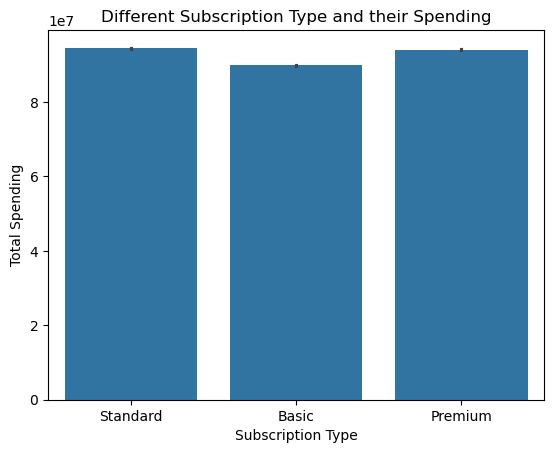

In [30]:
sns.barplot(data =data, x= 'Subscription Type',y = 'Total Spend',estimator = sum)
plt.title('Different Subscription Type and their Spending')
plt.xlabel('Subscription Type')
plt.ylabel('Total Spending')
plt.show()

In [31]:
data.groupby('Subscription Type')['Subscription Type'].count()

Subscription Type
Basic       143026
Premium     148678
Standard    149128
Name: Subscription Type, dtype: int64

In [32]:
# Spending is same almost does not matter which Subscription type they belonged to

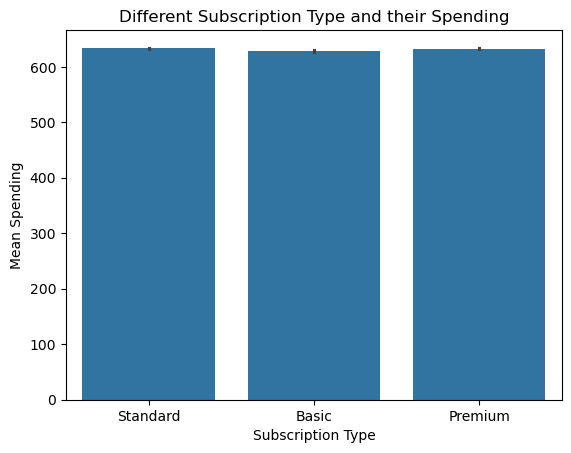

In [33]:
sns.barplot(data =data, x= 'Subscription Type',y = 'Total Spend',estimator = 'mean')
plt.title('Different Subscription Type and their Spending')
plt.xlabel('Subscription Type')
plt.ylabel('Mean Spending')
plt.show()

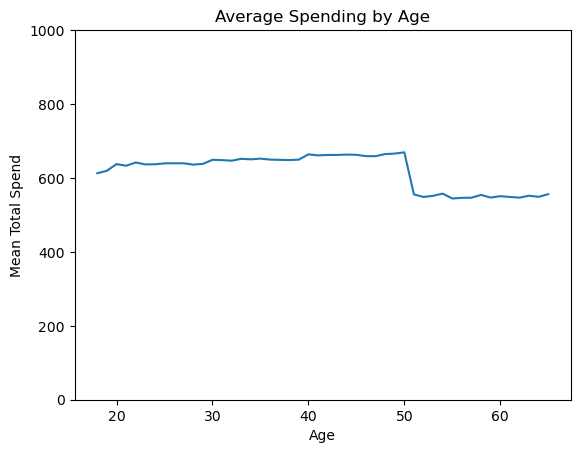

In [34]:
age_spend = data.groupby('Age')['Total Spend'].mean().reset_index()
sns.lineplot(data=age_spend, x='Age', y='Total Spend')
plt.title('Average Spending by Age')
plt.ylabel('Mean Total Spend')
plt.ylim(0, 1000) # Keep Y-axis grounded
plt.show()

In [35]:
# It tells that spending gets reduced after 50 years of age

In [36]:
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,AgeGroup
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,Mature
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,Old
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,Old
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,Old
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,Young


In [37]:
numCols = data[['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend','Last Interaction','Churn']]
numCols

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
0,30.0,39.0,14.0,5.0,18.0,932.00,17.0,1.0
1,65.0,49.0,1.0,10.0,8.0,557.00,6.0,1.0
2,55.0,14.0,4.0,6.0,18.0,185.00,3.0,1.0
3,58.0,38.0,21.0,7.0,7.0,396.00,29.0,1.0
4,23.0,32.0,20.0,5.0,8.0,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...
440828,42.0,54.0,15.0,1.0,3.0,716.38,8.0,0.0
440829,25.0,8.0,13.0,1.0,20.0,745.38,2.0,0.0
440830,26.0,35.0,27.0,1.0,5.0,977.31,9.0,0.0
440831,28.0,55.0,14.0,2.0,0.0,602.55,2.0,0.0


In [38]:
corr_matrix = numCols.corr()
corr_matrix

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394
Tenure,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919
Usage Frequency,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101
Support Calls,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267
Payment Delay,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129
Total Spend,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355
Last Interaction,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616
Churn,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000


In [39]:
# Support calls (+0.57) and payment delays (+0.31) are the strongest indicators of churn, 
# while higher total spend (-0.43) strongly correlates with customer retention.

In [40]:
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,AgeGroup
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,Mature
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,Old
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,Old
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,Old
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,Young


In [41]:
# Droping Age Group Column because it will overweight Age because there's another numerical column of age do exist

In [42]:
data = data.drop('AgeGroup',axis=1)
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [43]:
data.isnull().sum()

Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [44]:
data[data.isnull().any(axis=1)]

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# So from that we know that only 1 observation contains missing values, because its just one we can simply
# Drop that row

In [46]:
data = data.dropna()
data.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [47]:
# Now missing Values removed from our dataset

In [48]:
numCols.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [49]:
# Outlier handling
# Dataset values looks real from max to min range, So we don't need to either remove outliers or outlier capping

In [50]:
data = pd.get_dummies(data, columns=['Subscription Type','Contract Length'])
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,Female,39.0,14.0,5.0,18.0,932.0,17.0,1.0,False,False,True,True,False,False
1,65.0,Female,49.0,1.0,10.0,8.0,557.0,6.0,1.0,True,False,False,False,True,False
2,55.0,Female,14.0,4.0,6.0,18.0,185.0,3.0,1.0,True,False,False,False,False,True
3,58.0,Male,38.0,21.0,7.0,7.0,396.0,29.0,1.0,False,False,True,False,True,False
4,23.0,Male,32.0,20.0,5.0,8.0,617.0,20.0,1.0,True,False,False,False,True,False


In [51]:
cols = [
    'Subscription Type_Basic',
    'Subscription Type_Premium',
    'Subscription Type_Standard',
    'Contract Length_Annual',
    'Contract Length_Monthly',
    'Contract Length_Quarterly'
]

data[cols] = data[cols].astype(int)
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,Female,39.0,14.0,5.0,18.0,932.0,17.0,1.0,0,0,1,1,0,0
1,65.0,Female,49.0,1.0,10.0,8.0,557.0,6.0,1.0,1,0,0,0,1,0
2,55.0,Female,14.0,4.0,6.0,18.0,185.0,3.0,1.0,1,0,0,0,0,1
3,58.0,Male,38.0,21.0,7.0,7.0,396.0,29.0,1.0,0,0,1,0,1,0
4,23.0,Male,32.0,20.0,5.0,8.0,617.0,20.0,1.0,1,0,0,0,1,0


In [52]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

In [53]:
data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,0,0,1,1,0,0
1,65.0,0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,1,0,0,0,1,0
2,55.0,0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,1,0,0,0,0,1
3,58.0,1,38.0,21.0,7.0,7.0,396.0,29.0,1.0,0,0,1,0,1,0
4,23.0,1,32.0,20.0,5.0,8.0,617.0,20.0,1.0,1,0,0,0,1,0


In [54]:
# So all of our data is successully encoded numerically

In [55]:
data.corr()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
Age,1.000000,-0.031419,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394,0.004768,-0.002873,-0.001847,-0.034986,0.086909,-0.035617
Gender,-0.031419,1.000000,0.007978,0.007978,-0.091212,-0.048449,0.066138,0.134786,-0.175395,-0.000725,0.003189,-0.002469,0.029391,-0.067611,0.025533
Tenure,-0.011630,0.007978,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919,0.027270,-0.015415,-0.011580,0.009021,-0.020637,0.007744
Usage Frequency,-0.007190,0.007978,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101,0.000096,0.000149,-0.000244,0.006943,-0.017820,0.007534
Support Calls,0.158451,-0.091212,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267,0.010780,-0.006219,-0.004453,-0.091068,0.223242,-0.090289
Payment Delay,0.061738,-0.048449,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129,0.005085,-0.004229,-0.000805,-0.049697,0.122674,-0.049961
Total Spend,-0.084684,0.066138,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355,-0.008469,0.003882,0.004501,0.068365,-0.166916,0.067234
Last Interaction,0.028980,0.134786,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616,0.000615,-0.000438,-0.000171,-0.023342,0.057563,-0.023421
Churn,0.218394,-0.175395,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000,0.020526,-0.011072,-0.009247,-0.175965,0.433553,-0.176244
Subscription Type_Basic,0.004768,-0.000725,0.027270,0.000096,0.010780,0.005085,-0.008469,0.000615,0.020526,1.000000,-0.494377,-0.495506,-0.001345,0.009607,-0.006461


In [56]:
# Check pairwise correlations to find which features most strongly impact customer churn

In [57]:
# Now checking is the distribution of churn and non churn count same or not

In [58]:
data.groupby('Churn')['Churn'].count()

Churn
0.0    190833
1.0    249999
Name: Churn, dtype: int64

In [59]:
# It shows ratio is a bit imbalanced but still 190833 (the least one : No Churn/Retained) is enough for model to learn

In [60]:
from sklearn.model_selection import train_test_split
X = data.drop(columns=['Churn'])
y = data['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [61]:
# We Split our dataset into training and testing with ration of 80:20 and we use stratified sampling based on Churn
# so same proportion of Churn will go on both training and testing side

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.9972892352013792

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



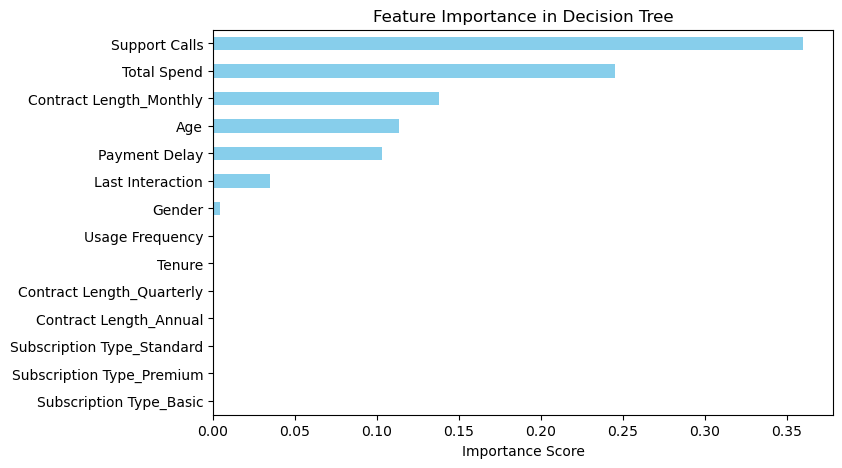

In [63]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
importance.plot(kind='barh', figsize=(8, 5), color='skyblue')
plt.title("Feature Importance in Decision Tree")
plt.xlabel("Importance Score")
plt.show()

In [64]:
# The Decision Tree achieved over 99% accuracy and precision on the test set, indicating excellent performance.
# Feature importance scores reveal that Support Calls is the single strongest predictor of churn (~37%), 
# followed by Total Spend, Contract Length_Monthly, Age, Payment Delay, and Last Interaction. 
# Subscription types and other contract lengths contributed negligible predictive power.

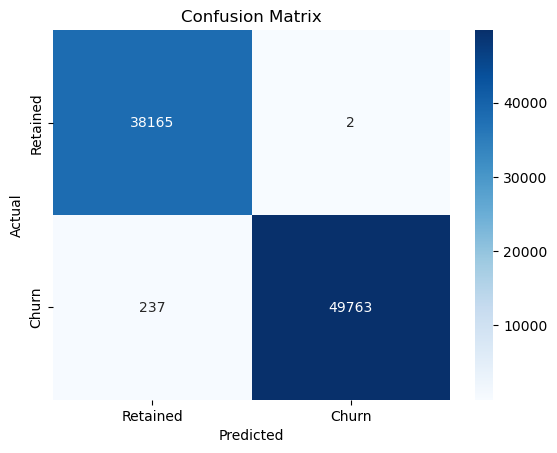

In [65]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Retained', 'Churn'], yticklabels=['Retained', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [66]:
# Confusion Matrix shows that only 239 prediction gets wrong only while approximately 88k predictions are correct

In [67]:
import joblib
joblib.dump(model, 'churn_model.pkl')

['churn_model.pkl']

In [68]:
# We have exported our model into our computer

In [69]:
!pip install gradio

  Using cached gradio-6.27.0-py3-none-any.whl.metadata (17 kB)
  Using cached audioop_lts-0.2.2-cp313-abi3-win_amd64.whl.metadata (2.0 kB)
  Using cached brotli-1.2.0-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached fastapi-0.141.1-py3-none-any.whl.metadata (27 kB)
  Using cached gradio_client-2.7.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_gradio-0.4.1-py3-none-any.whl.metadata (428 bytes)
  Using cached huggingface_hub-1.31.0-py3-none-any.whl.metadata (16 kB)
  Using cached orjson-3.12.0-cp313-cp313-win_amd64.whl.metadata (43 kB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached starlette-1.6.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached uvicorn-0.52

In [70]:
# Graphical Interface

In [75]:
import gradio as gr
import pandas as pd
import joblib
model = joblib.load('churn_model.pkl')

def predict_churn(age, tenure, usage_freq, support_calls, payment_delay, total_spend, last_interaction, monthly_contract, gender):
    raw_data = {
        'Age': age,
        'Tenure': tenure,
        'Usage Frequency': usage_freq,
        'Support Calls': support_calls,
        'Payment Delay': payment_delay,
        'Total Spend': total_spend,
        'Last Interaction': last_interaction,
        'Contract Length_Monthly': 1 if monthly_contract == "Monthly" else 0,
        'Contract Length_Quarterly': 1 if monthly_contract == "Quarterly" else 0,
        'Contract Length_Annual': 1 if monthly_contract == "Annual" else 0,
        'Subscription Type_Basic': 0,
        'Subscription Type_Premium': 0,
        'Subscription Type_Standard': 0,
        'Gender': 1 if gender == "Male" else 0 
    }
    
    input_data = pd.DataFrame([raw_data])[X_train.columns]
    
    prediction = model.predict(input_data)[0]
    return "Customer Will Churn" if prediction == 1 else "Customer Will Stay"

gui = gr.Interface(
    fn=predict_churn,
    inputs=[
        gr.Slider(18, 65, value=30, label="Age"),
        gr.Slider(1, 60, value=12, label="Tenure (Months)"),
        gr.Slider(1, 30, value=15, label="Usage Frequency"),
        gr.Slider(0, 10, value=2, label="Support Calls"),
        gr.Slider(0, 30, value=5, label="Payment Delay (Days)"),
        gr.Slider(100, 1000, value=500, label="Total Spend ($)"),
        gr.Slider(1, 30, value=10, label="Last Interaction (Days ago)"),
        gr.Radio(["Monthly", "Annual",'Quarterly'], value="Monthly", label="Contract Type"),
        gr.Radio(["Male", "Female"], value="Male", label="Gender")
    ],
    outputs="text",
    title="Customer Churn Prediction App"
)

gui.launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
